[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/espg/mortie/HEAD?labpath=examples%2FExampleUsage.ipynb)


In [1]:
import pandas as pd
import healpy as hp
import numpy as np

import mortie as mt

Download the data for this example [here](https://earth.gsfc.nasa.gov/sites/default/files/lab_cryo/data/polar_ice_altimetry/antarctic_and_greenland_drainage_systems/ant_grounded_drainagesystem_polygons.txt)

These are continental hydrologic basins.

In [2]:
basins = pd.read_csv('../mortie/tests/Ant_Grounded_DrainageSystem_Polygons.txt',
                     names=['Lat','Lon','basin'], sep=r'\s+')

In [3]:
# Subsetting to basin 4
b4 = basins[basins.basin == 4]

In [4]:
b4

,Lat,Lon,basin
196966,-71.013116,-10.087038,4
196967,-71.026350,-10.069613,4
196968,-71.038885,-10.057657,4
196969,-71.053623,-10.033951,4
196970,-71.066636,-10.006919,4
...,...,...,...
239366,-70.943902,-10.055204,4
239367,-70.965003,-10.086568,4
239368,-70.980942,-10.108149,4
239369,-70.993810,-10.123396,4


The healpix datum is a spherical spatial index tree (really a 'trei' since it divides the embedding space). The original formulation allows for 29 levels of the tree. mortie carries the order in a packed 64-bit word (the order-29 encoding), so it represents the full depth: the finest cell at order 29 is about 12 mm on a side. The table below sweeps every order from the base cells down to order 29, switching units from kilometres to metres to millimetres as the cells shrink:

In [5]:
# Resolution per tessellation order, generated from mortie.order2res (km) so the
# table can't drift from the package. Units step km -> m -> mm as cells shrink.
def readable_res(order):
    metres = mt.order2res(order) * 1000.0   # order2res returns km
    if metres >= 1000:
        return f'{metres / 1000:,.1f} km'
    if metres >= 1:
        return f'{metres:,.1f} m'
    return f'{metres * 1000:,.1f} mm'

for order in range(30):
    print(f'order {order:2d}:  {readable_res(order)}')

order  0:  6,519.6 km
order  1:  3,259.8 km
order  2:  1,629.9 km
order  3:  815.0 km
order  4:  407.5 km
order  5:  203.7 km
order  6:  101.9 km
order  7:  50.9 km
order  8:  25.5 km
order  9:  12.7 km
order 10:  6.4 km
order 11:  3.2 km
order 12:  1.6 km
order 13:  795.9 m
order 14:  397.9 m
order 15:  199.0 m
order 16:  99.5 m
order 17:  49.7 m
order 18:  24.9 m
order 19:  12.4 m
order 20:  6.2 m
order 21:  3.1 m
order 22:  1.6 m
order 23:  777.2 mm
order 24:  388.6 mm
order 25:  194.3 mm
order 26:  97.1 mm
order 27:  48.6 mm
order 28:  24.3 mm
order 29:  12.1 mm


There's more details at the [healpy tutorial](https://healpy.readthedocs.io/en/latest/tutorial.html), the [healpix primer](https://healpix.jpl.nasa.gov/pdf/intro.pdf), and [this presentation](https://dcc.ligo.org/public/0149/G1800186/003/healpix-multiresolution.pdf)

39


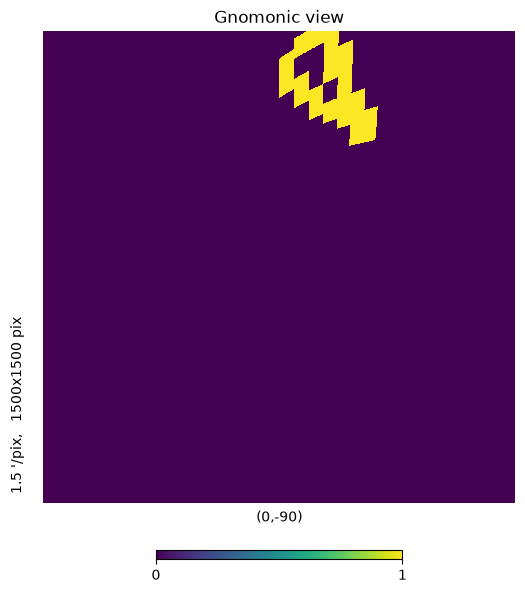

In [6]:
# Plotting coarse grid, level 6 of the tree with 100km grid cells
nside = 2**6
b2idx = hp.ang2pix(nside,b4.Lon.values, b4.Lat.values, lonlat=True) 
m = np.zeros(hp.nside2npix(nside))
m[np.unique(b2idx).ravel()] += 1
# Centered on the south pole
hp.gnomview(m, rot=[0,-90], xsize=1500, ysize=1500)# , nest=True)
print(len(np.unique(b2idx).ravel()))

In [7]:
np.unique(b2idx).ravel()

array([47848, 47849, 47948, 47949, 48043, 48044, 48045, 48046, 48135,
       48136, 48138, 48223, 48224, 48227, 48307, 48308, 48311, 48386,
       48387, 48390, 48391, 48461, 48462, 48463, 48465, 48466, 48467,
       48533, 48534, 48535, 48536, 48537, 48538, 48601, 48602, 48603,
       48604, 48605, 48666])

These are the healpix numbers level 6 of the tree. If we ask for them at a different level, they change in an unpredictable way:

380


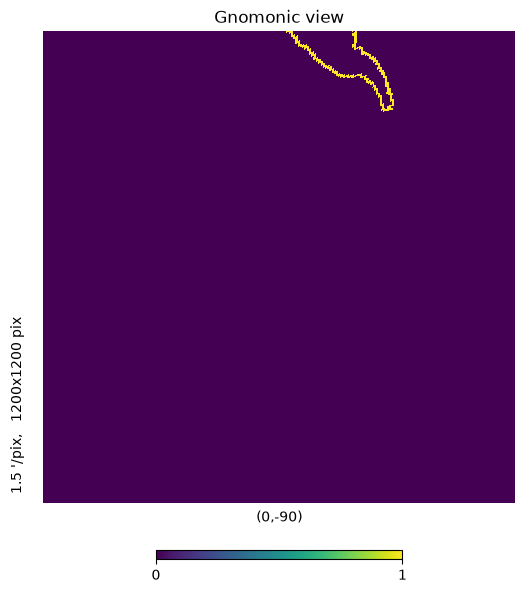

In [8]:
# Level 9 of the tree, up three orders of magnatude-- now the cells 12km in size, and there are more of them
nside = 2**9
b2idx = hp.ang2pix(nside,b4.Lon.values, b4.Lat.values, lonlat=True) 
m = np.zeros(hp.nside2npix(nside))
m[np.unique(b2idx).ravel()] += 1
# Centered on the south pole
hp.gnomview(m, rot=[0,-90], xsize=1200, ysize=1200)# , nest=True)
print(len(np.unique(b2idx).ravel()))

In [9]:
# Note that the new indices have no obvious relationship to the other indices at the lower resolution
np.unique(b2idx).ravel()

array([3059591, 3059592, 3060419, 3060420, 3061244, 3061245, 3062060,
       3062064, 3062065, 3062876, 3062877, 3062879, 3062880, 3062881,
       3062882, 3063688, 3063689, 3063691, 3063692, 3063693, 3063694,
       3064496, 3064498, 3064500, 3064502, 3065300, 3065303, 3065304,
       3065306, 3066101, 3066104, 3066106, 3066898, 3066899, 3066902,
       3067691, 3067692, 3067694, 3068479, 3068480, 3068482, 3069263,
       3069264, 3069267, 3070043, 3070044, 3070047, 3070819, 3070823,
       3071591, 3071596, 3072359, 3072365, 3073121, 3073122, 3073123,
       3073130, 3073880, 3073881, 3073882, 3073883, 3073890, 3074633,
       3074636, 3074637, 3074647, 3074651, 3075386, 3075387, 3075388,
       3075400, 3075401, 3075402, 3075403, 3076134, 3076135, 3076136,
       3076149, 3076150, 3076151, 3076152, 3076879, 3076896, 3077615,
       3077616, 3077617, 3077618, 3077619, 3077636, 3078351, 3078352,
       3078353, 3078354, 3078355, 3078373, 3079083, 3079105, 3079811,
       3079833, 3080

The reason that morton indexing exists, and is interesting, is that it encodes multiple resolutions of data in a meaningful and consistent way. Here's the same data, converted to tree level 9, but using mortie:

In [10]:
%%time

# geo2mort does the whole geographic -> morton encoding in one call
order = 9
mortons6 = mt.geo2mort(b4.Lat.values, b4.Lon.values, order=order)
print(len(np.unique(mortons6).ravel()))
np.unique(mortons6).ravel()

373
CPU times: user 3.57 ms, sys: 1.78 ms, total: 5.36 ms
Wall time: 1.65 ms


array([13860791025418633225, 13860799821511655433, 13860804219558166537,
       13860808617604677641, 13860870190255833097, 13860878986348855305,
       13860887782441877513, 13860892180488388617, 13860896578534899721,
       13860918568767455241, 13861160461325565961, 13861195645697654793,
       13861204441790677001, 13861208839837188105, 13861213237883699209,
       13861217635930210313, 13861222033976721417, 13861283606627876873,
       13861292402720899081, 13861296800767410185, 13861301198813921289,
       13861318790999965705, 13861327587092987913, 13861331985139499017,
       13861336383186010121, 13861340781232521225, 13861345179279032329,
       13861375965604610057, 13861380363651121161, 13861384761697632265,
       13861521101139476489, 13861525499185987593, 13861529897232498697,
       13861534295279009801, 13861538693325520905, 13861551887465054217,
       13863975211092672521, 13864019191557783561, 13864023589604294665,
       13864027987650805769, 13864032385697316873, 

373 cells here versus healpy's 380 above. healpy's `ang2pix` treats the latitudes as spherical; mortie's default (`latitude="authalic"`) first maps geodetic latitudes to the authalic sphere, so cells are equal-area on the WGS84 ellipsoid by construction. Points near cell edges can land one cell over, hence the different count -- passing `latitude="geodetic-spherical"` to `geo2mort` reproduces healpy's 380. Now if we go to a finer grid, we just clip the edge of the index:

In [11]:
# The same encoding at order 18, clipped back to order 6
mortons6 = mt.clip2order(6, mt.geo2mort(b4.Lat.values, b4.Lon.values, 18))
print(len(np.unique(mortons6)))
np.unique(mortons6)

40


array([13860672278162833414, 13860953753139544070, 13861235228116254726,
       13861516703092965382, 13863768502906650630, 13864049977883361286,
       13865457352766914566, 13865738827743625222, 13866583252673757190,
       13866864727650467846, 13867146202627178502, 13867427677603889158,
       13867709152580599814, 13867990627557310470, 13868272102534021126,
       13868835052487442438, 13907678599273512966, 13907960074250223622,
       13908241549226934278, 13908523024203644934, 13908804499180355590,
       13909367449133776902, 13910211874063908870, 13911056298994040838,
       13911337773970751494, 13911619248947462150, 13911900723924172806,
       13912463673877594118, 13913308098807726086, 13914152523737858054,
       13914433998714568710, 13914715473691279366, 13914996948667990022,
       13915278423644700678, 13915559898621411334, 13915841373598121990,
       13916122848574832646, 13916404323551543302, 13917248748481675270,
       13917530223458385926], dtype=uint64)

Why is this interesting? Let's say we have a petabyte of data, and we need to store it, query it, and generally interact with it. Given the structure above, we can define a file hierarchy to split the data, say using S3 buckets:

In [12]:
prefix = 's3://geostacks/icesat_2/top='
middle = '/mid='
cyc = '/cycle=8' # orbit cycle of icesat-2
suffix = '/atl06.parquet'

filelist = []

for s3dir in np.unique(mt.clip2order(4, mt.geo2mort(b4.Lat.values, b4.Lon.values, 18))):
    for a in [1,2,3,4]:
        for b in [1,2,3,4]:
            for c in [1,2,3,4]:
                filelist.append(prefix + str(s3dir) + middle + 
                                str(a)+str(b)+str(c) + 
                                cyc + suffix)

In [13]:
len(filelist)

384

In [14]:
np.random.choice(filelist, 40)

array(['s3://geostacks/icesat_2/top=13916122848574832644/mid=412/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13862079653046386692/mid=422/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13857576053419016196/mid=434/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13862079653046386692/mid=223/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13862079653046386692/mid=114/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13862079653046386692/mid=231/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13862079653046386692/mid=343/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13862079653046386692/mid=121/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13857576053419016196/mid=442/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13857576053419016196/mid=114/cycle=8/atl06.parquet',
       's3://geostacks/icesat_2/top=13907115649320091652/mid=322/cycle=8/atl06.parquet',
       's3://geostack

In reality, we'd have three levels of division in the s3 structure, not two, and they'd be balanced in terms of number of digits...but this example is more human readable.